Importing the required libraries

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

Importing the dataset

In [ ]:
df_netflix = pd.read_csv('netflix_titles.csv')

In [ ]:
# checking the first five rows of dataset
df_netflix.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [ ]:
# checking the last five rows of dataset
df_netflix.tail()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
8802,s8803,Movie,Zodiac,David Fincher,"Mark Ruffalo, Jake Gyllenhaal, Robert Downey J...",United States,"November 20, 2019",2007,R,158 min,"Cult Movies, Dramas, Thrillers","A political cartoonist, a crime reporter and a..."
8803,s8804,TV Show,Zombie Dumb,NaN,NaN,NaN,"July 1, 2019",2018,TV-Y7,2 Seasons,"Kids' TV, Korean TV Shows, TV Comedies","While living alone in a spooky town, a young g..."
8804,s8805,Movie,Zombieland,Ruben Fleischer,"Jesse Eisenberg, Woody Harrelson, Emma Stone, ...",United States,"November 1, 2019",2009,R,88 min,"Comedies, Horror Movies",Looking to survive in a world taken over by zo...
8805,s8806,Movie,Zoom,Peter Hewitt,"Tim Allen, Courteney Cox, Chevy Chase, Kate Ma...",United States,"January 11, 2020",2006,PG,88 min,"Children & Family Movies, Comedies","Dragged from civilian life, a former superhero..."
8806,s8807,Movie,Zubaan,Mozez Singh,"Vicky Kaushal, Sarah-Jane Dias, Raaghav Chanan...",India,"March 2, 2019",2015,TV-14,111 min,"Dramas, International Movies, Music & Musicals",A scrappy but poor boy worms his way into a ty...


In [ ]:
# checking the number of rows and columns
df_netflix.shape

(8807, 12)

In [ ]:
# checking the columns information
df_netflix.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


In [ ]:
# checking the null values in the dataset
df_netflix.isna().sum()

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

In [ ]:
# filling the null values with random data
df_netflix['director'].fillna("No Director",inplace=True)
df_netflix['cast'].fillna("No Cast",inplace=True)
df_netflix['country'].fillna("Country Unavailable",inplace=True)

In [ ]:
# dropping the null values which is less than 10%
df_netflix = df_netflix.dropna(subset=['date_added','rating','duration'])

In [ ]:
# checking if there any duplicate values are present
df_netflix[df_netflix.duplicated()]

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description


1. How many records are in the dataset?

In [ ]:
df_netflix.shape

(8790, 12)

2. How many unique types (movies/TV-shows) are present in the dataset?

In [ ]:
# finding the unique types
df_netflix['type'].value_counts()

Movie      6126
TV Show    2664
Name: type, dtype: int64

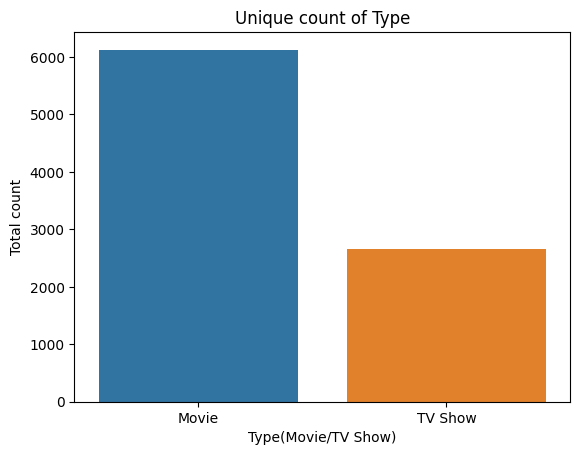

In [ ]:
# plotting the graph for same
sns.countplot(x='type',data=df_netflix)
plt.title('Unique count of Type')
plt.xlabel('Type(Movie/TV Show)')
plt.ylabel('Total count')
plt.show()

3. What is the distribution of ratings (G, PG, PG-13, etc.) in the dataset?

In [ ]:
df_netflix['rating'].value_counts()

TV-MA       3205
TV-14       2157
TV-PG        861
R            799
PG-13        490
TV-Y7        333
TV-Y         306
PG           287
TV-G         220
NR            79
G             41
TV-Y7-FV       6
NC-17          3
UR             3
Name: rating, dtype: int64

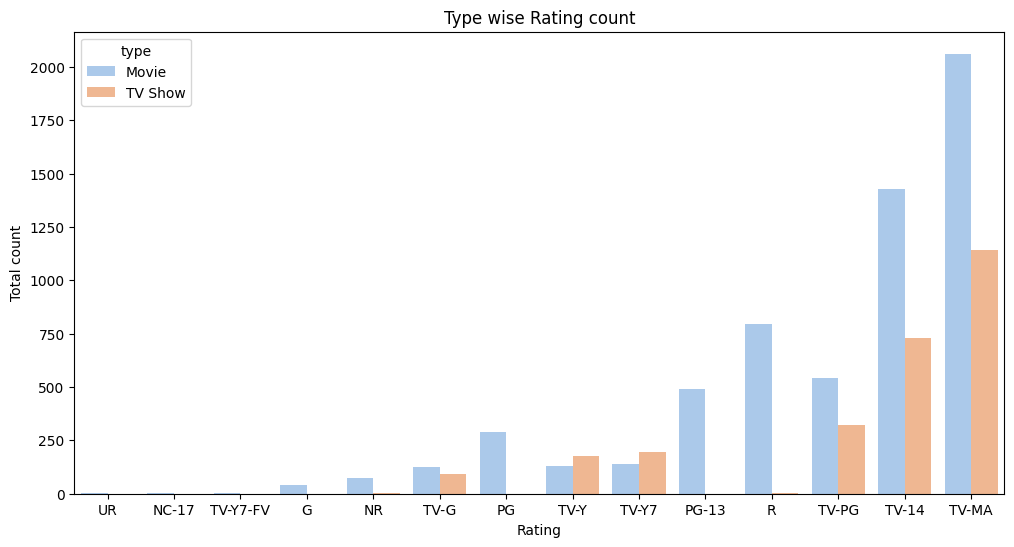

In [ ]:
order = ['UR', 'NC-17', 'TV-Y7-FV', 'G', 'NR', 'TV-G', 'PG', 'TV-Y', 'TV-Y7', 'PG-13', 'R', 'TV-PG','TV-14','TV-MA']
plt.figure(figsize=(12,6))
sns.countplot(x='rating',hue='type',palette='pastel',order=order,data=df_netflix)
plt.title('Type wise Rating count')
plt.xlabel('Rating')
plt.ylabel('Total count')
plt.show()

4. What is the average duration of movies and TV-shows?

In [ ]:
#df_netflix['duration'] = df_netflix['duration'].str.replace(' min','')
#df_netflix.replace({'duration':{'1 Season':'1 Seasons'}}, inplace=True)
#df_netflix['duration'] = df_netflix['duration'].str.replace(' Seasons','')

In [ ]:
# preparing the duration column
df_netflix['duration'] = df_netflix.apply(lambda x : x['duration'].split(" ")[0] if "Season" in x['duration'] else x['duration'], axis = 1)
df_netflix['duration'] = df_netflix.apply(lambda x : x['duration'].split(" ")[0] if "min" in x['duration'] else x['duration'], axis = 1)

In [ ]:
# changing the data type of duration to calculate
df_netflix['duration'] = df_netflix['duration'].astype(int)

In [ ]:
df_netflix

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,No Cast,United States,"September 25, 2021",2020,PG-13,90,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,No Director,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",Country Unavailable,"September 24, 2021",2021,TV-MA,1,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,No Director,No Cast,Country Unavailable,"September 24, 2021",2021,TV-MA,1,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,No Director,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...
...,...,...,...,...,...,...,...,...,...,...,...,...
8802,s8803,Movie,Zodiac,David Fincher,"Mark Ruffalo, Jake Gyllenhaal, Robert Downey J...",United States,"November 20, 2019",2007,R,158,"Cult Movies, Dramas, Thrillers","A political cartoonist, a crime reporter and a..."
8803,s8804,TV Show,Zombie Dumb,No Director,No Cast,Country Unavailable,"July 1, 2019",2018,TV-Y7,2,"Kids' TV, Korean TV Shows, TV Comedies","While living alone in a spooky town, a young g..."
8804,s8805,Movie,Zombieland,Ruben Fleischer,"Jesse Eisenberg, Woody Harrelson, Emma Stone, ...",United States,"November 1, 2019",2009,R,88,"Comedies, Horror Movies",Looking to survive in a world taken over by zo...
8805,s8806,Movie,Zoom,Peter Hewitt,"Tim Allen, Courteney Cox, Chevy Chase, Kate Ma...",United States,"January 11, 2020",2006,PG,88,"Children & Family Movies, Comedies","Dragged from civilian life, a former superhero..."


In [ ]:
df_netflix.groupby('type')[['duration']].mean()

,duration
type,
Movie,99.584884
TV Show,1.751877


5. Which director has the most content on Netflix?

In [ ]:
# taking top 10 director who owns most content
df_netflix.groupby('director')['type'].count().sort_values(ascending=False)[:10]

director
No Director               2621
Rajiv Chilaka               19
Raúl Campos, Jan Suter      18
Marcus Raboy                16
Suhas Kadav                 16
Jay Karas                   14
Cathy Garcia-Molina         13
Jay Chapman                 12
Youssef Chahine             12
Martin Scorsese             12
Name: type, dtype: int64

Since the director column mostly contains null values the most are No Director

6. Which country produces the most content on Netflix?

In [ ]:
# taking top 12 countries produces most content
df_mst_cnt = df_netflix.groupby('country')['type'].count().sort_values(ascending=False)[:12]
df_mst_cnt

country
United States          2809
India                   972
Country Unavailable     829
United Kingdom          418
Japan                   243
South Korea             199
Canada                  181
Spain                   145
France                  124
Mexico                  110
Egypt                   106
Turkey                  105
Name: type, dtype: int64

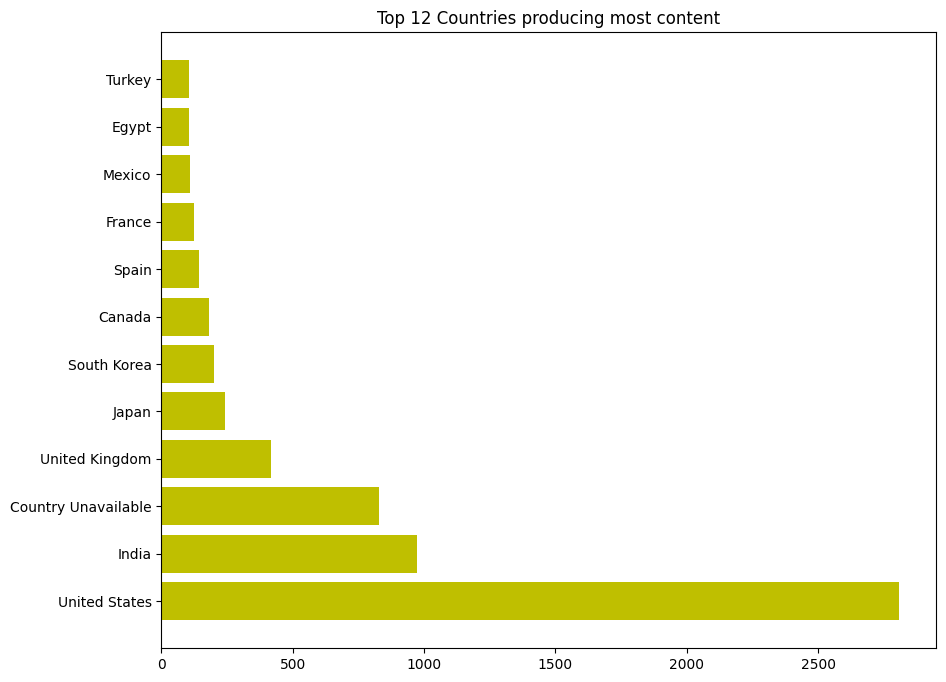

In [ ]:
plt.figure(figsize=(10,8))
plt.barh(df_mst_cnt.index,df_mst_cnt.values,color='y')
plt.title('Top 12 Countries producing most content')
plt.show()

7. How has the number of content additions evolved over the years?

In [ ]:
# changing the data type of date_added from object to datetime
df_netflix['date_added'] = pd.to_datetime(df_netflix['date_added'])

In [ ]:
# extracting year from date_added
df_netflix['year_added'] = df_netflix['date_added'].dt.year

In [ ]:
df_ad_ech_yr = df_netflix.groupby('year_added')[['type']].count().sort_values('type',ascending=False).reset_index()
df_ad_ech_yr = df_ad_ech_yr.rename(columns={'year_added':'Year','type':'Count'})
df_ad_ech_yr

,Year,Count
0,2019,2016
1,2020,1879
2,2018,1648
3,2021,1498
4,2017,1185
5,2016,426
6,2015,82
7,2014,24
8,2011,13
9,2013,11


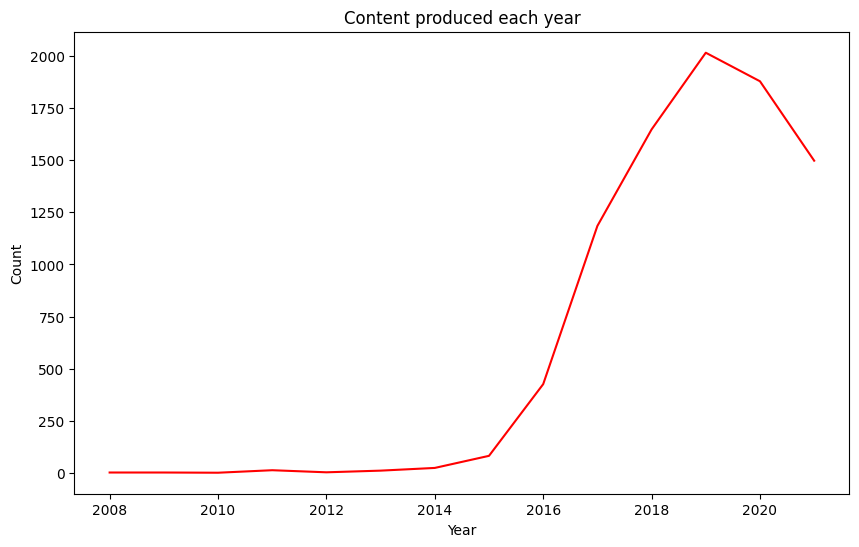

In [ ]:
plt.figure(figsize=(10,6))
sns.lineplot(x='Year',y='Count',data=df_ad_ech_yr,color='r')
plt.title('Content produced each year')
plt.show()

8. What are the top 5 countries with the highest average ratings?

In [ ]:
# converting country and rating as key value pair
dict1 = {}
def add_rating(country,rating,dict1):
  all_countries = country.split(',')
  for i in all_countries:
    if i.strip() in dict1:
      dict1[i.strip()].append(rating)
    else:
      dict1[i.strip()]=[]
      dict1[i.strip()].append(rating)
  return dict1

for i in df_netflix[['country','rating']].values:
  dict1=add_rating(i[0],i[1],dict1)

In [ ]:
dict1

{'United States': ['PG-13',
  'TV-MA',
  'PG-13',
  'TV-MA',
  'PG-13',
  'PG-13',
  'PG-13',
  'PG-13',
  'TV-Y7',
  'PG',
  'PG',
  'PG',
  'PG-13',
  'R',
  'R',
  'TV-PG',
  'TV-PG',
  'R',
  'TV-14',
  'TV-MA',
  'PG',
  'TV-MA',
  'TV-MA',
  'TV-Y7',
  'TV-MA',
  'TV-MA',
  'TV-G',
  'G',
  'TV-Y',
  'PG-13',
  'R',
  'TV-MA',
  'PG',
  'PG-13',
  'R',
  'R',
  'PG-13',
  'R',
  'R',
  'PG',
  'PG-13',
  'R',
  'R',
  'PG-13',
  'PG-13',
  'R',
  'R',
  'R',
  'R',
  'R',
  'TV-MA',
  'PG',
  'PG',
  'PG-13',
  'TV-PG',
  'PG-13',
  'PG-13',
  'R',
  'PG-13',
  'R',
  'PG',
  'PG',
  'PG-13',
  'R',
  'PG-13',
  'PG-13',
  'PG-13',
  'R',
  'R',
  'PG-13',
  'TV-14',
  'R',
  'PG-13',
  'PG-13',
  'R',
  'TV-PG',
  'R',
  'TV-PG',
  'TV-MA',
  'R',
  'TV-MA',
  'PG',
  'TV-G',
  'TV-14',
  'R',
  'PG-13',
  'TV-Y',
  'TV-Y',
  'R',
  'R',
  'TV-MA',
  'TV-Y7',
  'TV-MA',
  'TV-PG',
  'TV-PG',
  'TV-14',
  'TV-Y',
  'TV-MA',
  'PG-13',
  'TV-MA',
  'PG',
  'TV-MA',
  'TV-MA',
  'T

In [ ]:
# calculating the count of rating for each country
dict2 = {}
for key,value in sorted(dict1.items()):
  dict2[key] = len(value)
print(dict2)

{'': 7, 'Afghanistan': 1, 'Albania': 1, 'Algeria': 3, 'Angola': 1, 'Argentina': 91, 'Armenia': 1, 'Australia': 158, 'Austria': 12, 'Azerbaijan': 1, 'Bahamas': 1, 'Bangladesh': 4, 'Belarus': 1, 'Belgium': 90, 'Bermuda': 1, 'Botswana': 1, 'Brazil': 97, 'Bulgaria': 10, 'Burkina Faso': 1, 'Cambodia': 6, 'Cameroon': 1, 'Canada': 445, 'Cayman Islands': 2, 'Chile': 29, 'China': 162, 'Colombia': 52, 'Country Unavailable': 829, 'Croatia': 4, 'Cuba': 1, 'Cyprus': 1, 'Czech Republic': 22, 'Denmark': 48, 'Dominican Republic': 1, 'East Germany': 1, 'Ecuador': 1, 'Egypt': 117, 'Ethiopia': 1, 'Finland': 11, 'France': 393, 'Georgia': 2, 'Germany': 226, 'Ghana': 5, 'Greece': 11, 'Guatemala': 2, 'Hong Kong': 105, 'Hungary': 11, 'Iceland': 11, 'India': 1046, 'Indonesia': 90, 'Iran': 4, 'Iraq': 2, 'Ireland': 46, 'Israel': 30, 'Italy': 99, 'Jamaica': 1, 'Japan': 316, 'Jordan': 9, 'Kazakhstan': 1, 'Kenya': 6, 'Kuwait': 8, 'Latvia': 1, 'Lebanon': 31, 'Liechtenstein': 1, 'Lithuania': 1, 'Luxembourg': 12, 'Mal

In [ ]:
# sorting the top 5 dictionary in descending order of value
desc_srtd_ = sorted(dict2.items(), key=lambda x:x[1],reverse=True)
desc_srtd_[:5]

[('United States', 3681),
 ('India', 1046),
 ('Country Unavailable', 829),
 ('United Kingdom', 805),
 ('Canada', 445)]

In [ ]:
# unzippin the top 5 list of tuples into list of lists
unzipped_lst = [list(i) for i in zip(*desc_srtd_[:5])]
unzipped_lst

[['United States', 'India', 'Country Unavailable', 'United Kingdom', 'Canada'],
 [3681, 1046, 829, 805, 445]]

In [ ]:
# assinging the lists to different variables
labels = unzipped_lst[0]
values = unzipped_lst[1]
print(labels)
print(values)

['United States', 'India', 'Country Unavailable', 'United Kingdom', 'Canada']
[3681, 1046, 829, 805, 445]


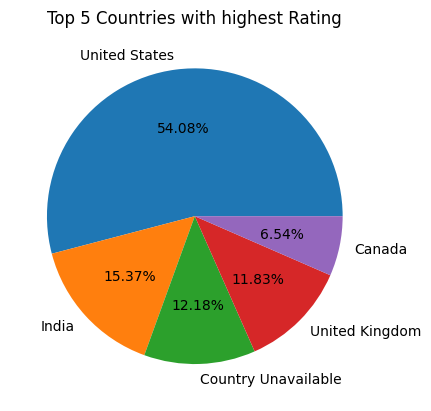

In [ ]:
plt.pie(values,labels=labels,autopct='%0.2f%%')
plt.title('Top 5 Countries with highest Rating')
plt.show()

9. What are the most common genres listed in the "listed_in" column?

In [ ]:
# extracting the listed_in column as list
my_lst = list(df_netflix['listed_in'])
my_lst

['Documentaries',
 'International TV Shows, TV Dramas, TV Mysteries',
 'Crime TV Shows, International TV Shows, TV Action & Adventure',
 'Docuseries, Reality TV',
 'International TV Shows, Romantic TV Shows, TV Comedies',
 'TV Dramas, TV Horror, TV Mysteries',
 'Children & Family Movies',
 'Dramas, Independent Movies, International Movies',
 'British TV Shows, Reality TV',
 'Comedies, Dramas',
 'Crime TV Shows, Docuseries, International TV Shows',
 'Crime TV Shows, International TV Shows, TV Action & Adventure',
 'Dramas, International Movies',
 'Children & Family Movies, Comedies',
 'British TV Shows, Crime TV Shows, Docuseries',
 'TV Comedies, TV Dramas',
 'Documentaries, International Movies',
 'Crime TV Shows, Spanish-Language TV Shows, TV Dramas',
 'Thrillers',
 'International TV Shows, Spanish-Language TV Shows, TV Action & Adventure',
 'Crime TV Shows, Docuseries, International TV Shows',
 'International TV Shows, TV Action & Adventure, TV Dramas',
 'Comedies, International Movi

In [ ]:
# converting the list in str to split
new_lst = str(my_lst).split(',')
new_lst

["['Documentaries'",
 " 'International TV Shows",
 ' TV Dramas',
 " TV Mysteries'",
 " 'Crime TV Shows",
 ' International TV Shows',
 " TV Action & Adventure'",
 " 'Docuseries",
 " Reality TV'",
 " 'International TV Shows",
 ' Romantic TV Shows',
 " TV Comedies'",
 " 'TV Dramas",
 ' TV Horror',
 " TV Mysteries'",
 " 'Children & Family Movies'",
 " 'Dramas",
 ' Independent Movies',
 " International Movies'",
 " 'British TV Shows",
 " Reality TV'",
 " 'Comedies",
 " Dramas'",
 " 'Crime TV Shows",
 ' Docuseries',
 " International TV Shows'",
 " 'Crime TV Shows",
 ' International TV Shows',
 " TV Action & Adventure'",
 " 'Dramas",
 " International Movies'",
 " 'Children & Family Movies",
 " Comedies'",
 " 'British TV Shows",
 ' Crime TV Shows',
 " Docuseries'",
 " 'TV Comedies",
 " TV Dramas'",
 " 'Documentaries",
 " International Movies'",
 " 'Crime TV Shows",
 ' Spanish-Language TV Shows',
 " TV Dramas'",
 " 'Thrillers'",
 " 'International TV Shows",
 ' Spanish-Language TV Shows',
 " TV 

In [ ]:
# converting the list in dict as key and count of key as value
my_dict = {key:new_lst.count(key) for key in new_lst}
my_dict

{"['Documentaries'": 1,
 " 'International TV Shows": 770,
 ' TV Dramas': 133,
 " TV Mysteries'": 76,
 " 'Crime TV Shows": 396,
 ' International TV Shows': 355,
 " TV Action & Adventure'": 46,
 " 'Docuseries": 135,
 " Reality TV'": 103,
 ' Romantic TV Shows': 223,
 " TV Comedies'": 258,
 " 'TV Dramas": 32,
 ' TV Horror': 30,
 " 'Children & Family Movies'": 215,
 " 'Dramas": 1462,
 ' Independent Movies': 424,
 " International Movies'": 1786,
 " 'British TV Shows": 221,
 " 'Comedies": 1100,
 " Dramas'": 173,
 ' Docuseries': 91,
 " International TV Shows'": 221,
 " 'Children & Family Movies": 390,
 " Comedies'": 264,
 ' Crime TV Shows': 68,
 " Docuseries'": 83,
 " 'TV Comedies": 51,
 " TV Dramas'": 551,
 " 'Documentaries": 470,
 ' Spanish-Language TV Shows': 57,
 " 'Thrillers'": 65,
 ' TV Action & Adventure': 78,
 ' International Movies': 838,
 " Romantic Movies'": 597,
 " Music & Musicals'": 337,
 " 'Comedies'": 110,
 " 'Horror Movies": 220,
 " Sci-Fi & Fantasy'": 205,
 " 'TV Comedies'": 

In [ ]:
# sorting the dict in descending order by value
desc_srtd_1 = sorted(my_dict.items(), key=lambda x:x[1],reverse=True)
desc_srtd_1

[(" International Movies'", 1786),
 (" 'Dramas", 1462),
 (" 'Comedies", 1100),
 (' International Movies', 838),
 (" 'International TV Shows", 770),
 (" 'Action & Adventure", 731),
 (' Dramas', 654),
 (" Romantic Movies'", 597),
 (" TV Dramas'", 551),
 (" Thrillers'", 512),
 (" 'Documentaries", 470),
 (' Independent Movies', 424),
 (" 'Crime TV Shows", 396),
 (" 'Children & Family Movies", 390),
 (" 'Documentaries'", 358),
 (' International TV Shows', 355),
 (" Music & Musicals'", 337),
 (" 'Stand-Up Comedy'", 334),
 (" Independent Movies'", 312),
 (" Comedies'", 264),
 (" TV Comedies'", 258),
 (' Romantic TV Shows', 223),
 (" 'British TV Shows", 221),
 (" International TV Shows'", 221),
 (" 'Horror Movies", 220),
 (' "Kids\' TV"', 219),
 (" Sports Movies'", 218),
 (" 'Children & Family Movies'", 215),
 (" Sci-Fi & Fantasy'", 205),
 (' Comedies', 200),
 (" Dramas'", 173),
 (' "Kids\' TV', 166),
 (" 'Anime Series", 140),
 (" 'Dramas'", 137),
 (" 'Docuseries", 135),
 (' TV Dramas', 133),


In [ ]:
# unzippig the top 10 list of tuples into list of lists
unzipped_lst_1 = [list(i) for i in zip(*desc_srtd_1[:10])]
unzipped_lst_1

[[" International Movies'",
  " 'Dramas",
  " 'Comedies",
  ' International Movies',
  " 'International TV Shows",
  " 'Action & Adventure",
  ' Dramas',
  " Romantic Movies'",
  " TV Dramas'",
  " Thrillers'"],
 [1786, 1462, 1100, 838, 770, 731, 654, 597, 551, 512]]

In [ ]:
# extracting the lists into label and value
label = unzipped_lst_1[0]
value = unzipped_lst_1[1]

print(label)
print(value)

[" International Movies'", " 'Dramas", " 'Comedies", ' International Movies', " 'International TV Shows", " 'Action & Adventure", ' Dramas', " Romantic Movies'", " TV Dramas'", " Thrillers'"]
[1786, 1462, 1100, 838, 770, 731, 654, 597, 551, 512]


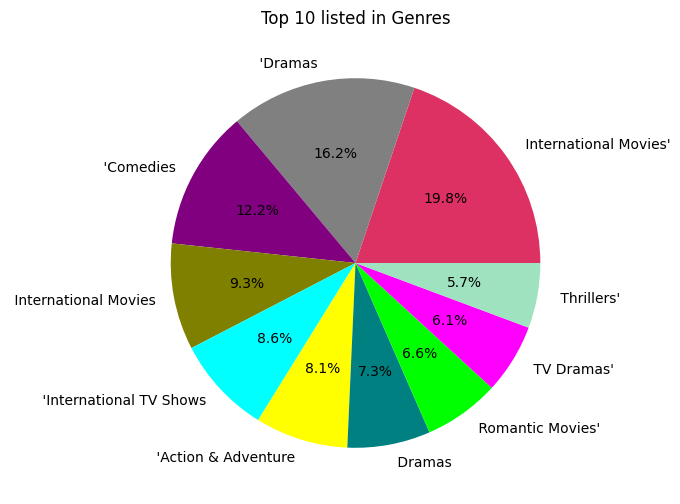

In [ ]:
plt.figure(figsize=(6,6))
plt.pie(value,labels=label,autopct='%0.1f%%',colors=['#DE3163','#808080','#800080','#808000','#00FFFF','#FFFF00','#008080','#00FF00','#FF00FF','#9FE2BF'])
plt.title('Top 10 listed in Genres')
plt.show()

10. What are the oldest and newest releases in the dataset?

In [ ]:
# taking top 15 oldest releases
df_asc_rel = df_netflix[['show_id','type','title','date_added','release_year']].sort_values('release_year').reset_index()
df_asc_rel.drop('index',axis=1,inplace=True)
df_asc_rel.head(15)

,show_id,type,title,date_added,release_year
0,s4251,TV Show,Pioneers: First Women Filmmakers*,2018-12-30,1925
1,s7791,Movie,Prelude to War,2017-03-31,1942
2,s8206,Movie,The Battle of Midway,2017-03-31,1942
3,s8764,Movie,WWII: Report from the Aleutians,2017-03-31,1943
4,s8740,Movie,Why We Fight: The Battle of Russia,2017-03-31,1943
5,s8661,Movie,Undercover: How to Operate Behind Enemy Lines,2017-03-31,1943
6,s8420,Movie,The Memphis Belle: A Story of a\nFlying Fortress,2017-03-31,1944
7,s8641,Movie,Tunisian Victory,2017-03-31,1944
8,s8437,Movie,The Negro Soldier,2017-03-31,1944
9,s7576,Movie,Nazi Concentration Camps,2017-03-31,1945


In [ ]:
# taking top 10 newest releases
df_dsc_rel = df_netflix[['show_id','type','title','date_added','release_year']].sort_values('release_year',ascending=False).reset_index()
df_dsc_rel.drop('index',axis=1,inplace=True)
df_dsc_rel.head(10)

,show_id,type,title,date_added,release_year
0,s694,Movie,Ali & Ratu Ratu Queens,2021-06-17,2021
1,s782,Movie,Black Holes | The Edge of All We Know,2021-06-02,2021
2,s763,Movie,Sweet & Sour,2021-06-04,2021
3,s764,TV Show,Sweet Tooth,2021-06-04,2021
4,s765,Movie,Trippin' with the Kandasamys,2021-06-04,2021
5,s766,Movie,Xtreme,2021-06-04,2021
6,s767,Movie,Alan Saldaña: Locked Up,2021-06-03,2021
7,s768,TV Show,Creator's File: GOLD,2021-06-03,2021
8,s769,Movie,Dancing Queens,2021-06-03,2021
9,s771,Movie,Myriam Fares: The Journey,2021-06-03,2021


11. Who are the top 5 most frequent actors/actresses in the "cast" column?

In [ ]:
# extracting the cast column as list
df_cast = list(df_netflix['cast'])
df_cast

['No Cast',
 'Ama Qamata, Khosi Ngema, Gail Mabalane, Thabang Molaba, Dillon Windvogel, Natasha Thahane, Arno Greeff, Xolile Tshabalala, Getmore Sithole, Cindy Mahlangu, Ryle De Morny, Greteli Fincham, Sello Maake Ka-Ncube, Odwa Gwanya, Mekaila Mathys, Sandi Schultz, Duane Williams, Shamilla Miller, Patrick Mofokeng',
 'Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabiha Akkari, Sofia Lesaffre, Salim Kechiouche, Noureddine Farihi, Geert Van Rampelberg, Bakary Diombera',
 'No Cast',
 'Mayur More, Jitendra Kumar, Ranjan Raj, Alam Khan, Ahsaas Channa, Revathi Pillai, Urvi Singh, Arun Kumar',
 'Kate Siegel, Zach Gilford, Hamish Linklater, Henry Thomas, Kristin Lehman, Samantha Sloyan, Igby Rigney, Rahul Kohli, Annarah Cymone, Annabeth Gish, Alex Essoe, Rahul Abburi, Matt Biedel, Michael Trucco, Crystal Balint, Louis Oliver',
 'Vanessa Hudgens, Kimiko Glenn, James Marsden, Sofia Carson, Liza Koshy, Ken Jeong, Elizabeth Perkins, Jane Krakowski, Michael McKean, Phil LaMarr',
 'Kofi Ghanaba, Oyaf

In [ ]:
# converting the list into str to split
new_lst1 = str(df_cast).split(',')
new_lst1

["['No Cast'",
 " 'Ama Qamata",
 ' Khosi Ngema',
 ' Gail Mabalane',
 ' Thabang Molaba',
 ' Dillon Windvogel',
 ' Natasha Thahane',
 ' Arno Greeff',
 ' Xolile Tshabalala',
 ' Getmore Sithole',
 ' Cindy Mahlangu',
 ' Ryle De Morny',
 ' Greteli Fincham',
 ' Sello Maake Ka-Ncube',
 ' Odwa Gwanya',
 ' Mekaila Mathys',
 ' Sandi Schultz',
 ' Duane Williams',
 ' Shamilla Miller',
 " Patrick Mofokeng'",
 " 'Sami Bouajila",
 ' Tracy Gotoas',
 ' Samuel Jouy',
 ' Nabiha Akkari',
 ' Sofia Lesaffre',
 ' Salim Kechiouche',
 ' Noureddine Farihi',
 ' Geert Van Rampelberg',
 " Bakary Diombera'",
 " 'No Cast'",
 " 'Mayur More",
 ' Jitendra Kumar',
 ' Ranjan Raj',
 ' Alam Khan',
 ' Ahsaas Channa',
 ' Revathi Pillai',
 ' Urvi Singh',
 " Arun Kumar'",
 " 'Kate Siegel",
 ' Zach Gilford',
 ' Hamish Linklater',
 ' Henry Thomas',
 ' Kristin Lehman',
 ' Samantha Sloyan',
 ' Igby Rigney',
 ' Rahul Kohli',
 ' Annarah Cymone',
 ' Annabeth Gish',
 ' Alex Essoe',
 ' Rahul Abburi',
 ' Matt Biedel',
 ' Michael Trucco',

In [ ]:
# converting list into dictionary as key and value as count of key
my_dict1 = [wrd for wrd in new_lst1]

wrd_cnts = Counter(my_dict1)
wrd_cnts

Counter({"['No Cast'": 1,
         " 'Ama Qamata": 1,
         ' Khosi Ngema': 1,
         ' Gail Mabalane': 1,
         ' Thabang Molaba': 2,
         ' Dillon Windvogel': 1,
         ' Natasha Thahane': 1,
         ' Arno Greeff': 1,
         ' Xolile Tshabalala': 1,
         ' Getmore Sithole': 1,
         ' Cindy Mahlangu': 2,
         ' Ryle De Morny': 1,
         ' Greteli Fincham': 1,
         ' Sello Maake Ka-Ncube': 1,
         ' Odwa Gwanya': 1,
         ' Mekaila Mathys': 1,
         ' Sandi Schultz': 1,
         ' Duane Williams': 1,
         ' Shamilla Miller': 1,
         " Patrick Mofokeng'": 1,
         " 'Sami Bouajila": 2,
         ' Tracy Gotoas': 1,
         ' Samuel Jouy': 3,
         ' Nabiha Akkari': 1,
         ' Sofia Lesaffre': 1,
         ' Salim Kechiouche': 2,
         ' Noureddine Farihi': 1,
         ' Geert Van Rampelberg': 1,
         " Bakary Diombera'": 2,
         " 'No Cast'": 824,
         " 'Mayur More": 1,
         ' Jitendra Kumar': 1,
         

In [ ]:
# sorting the dictionary by value
desc_val = sorted(wrd_cnts.items(), key=lambda x:x[1],reverse=True)
desc_val

[(" 'No Cast'", 824),
 (' Anupam Kher', 37),
 (' Rupa Bhimani', 31),
 (' Takahiro Sakurai', 29),
 (' Julie Tejwani', 28),
 (' Om Puri', 27),
 (" 'Shah Rukh Khan", 26),
 (' Paresh Rawal', 25),
 (' Andrea Libman', 24),
 (' Jigna Bhardwaj', 23),
 (' Rajesh Kava', 22),
 (' Vincent Tong', 22),
 (' Yuki Kaji', 22),
 (" 'Akshay Kumar", 21),
 (' Junichi Suwabe', 20),
 (" 'Amitabh Bachchan", 20),
 (' Kareena Kapoor', 20),
 (' Fred Tatasciore', 19),
 (" 'David Attenborough'", 19),
 (' Boman Irani', 19),
 (" 'Adam Sandler", 18),
 (" 'Vatsal Dubey", 18),
 (' Yashpal Sharma', 18),
 (' Daisuke Ono', 17),
 (' Ai Kayano', 17),
 (' Kana Hanazawa', 17),
 (' Gulshan Grover', 17),
 (' Yuichi Nakamura', 16),
 (' Naseeruddin Shah', 16),
 (' John Cleese', 16),
 (' Kay Kay Menon', 16),
 (' Alessandro Juliani', 16),
 (' Amrish Puri', 16),
 (' Maya Rudolph', 15),
 (' Miyuki Sawashiro', 15),
 (' Erin Fitzgerald', 15),
 (' Tinnu Anand', 15),
 (' Samuel L. Jackson', 15),
 (" 'Ajay Devgn", 15),
 (' Rajesh Sharma', 

In [ ]:
# unzipping the list of tuples into list of lists and taking value from 1 to 6 in slicing because 0th index has 'No cast' element
unzipp_lst = [list(i) for i in zip(*desc_val[1:6])]
unzipp_lst

[[' Anupam Kher',
  ' Rupa Bhimani',
  ' Takahiro Sakurai',
  ' Julie Tejwani',
  ' Om Puri'],
 [37, 31, 29, 28, 27]]

In [ ]:
# extracting the lists into x and y
x = unzipp_lst[0]
y = unzipp_lst[1]

print(x)
print(y)

[' Anupam Kher', ' Rupa Bhimani', ' Takahiro Sakurai', ' Julie Tejwani', ' Om Puri']
[37, 31, 29, 28, 27]


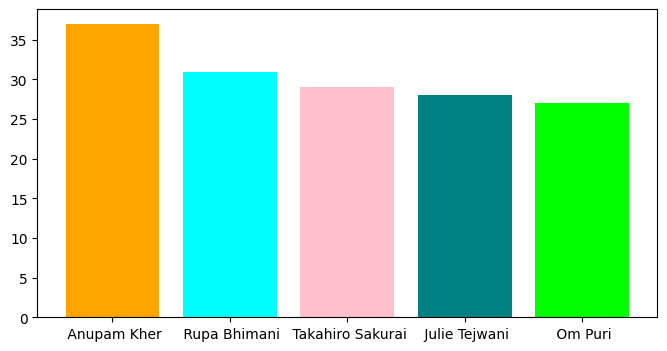

In [ ]:
plt.figure(figsize=(8,4))
plt.bar(x,y,color=['orange','aqua','pink','teal','lime'])
plt.show()

12. How many TV-shows and movies were added to Netflix each year?

In [ ]:
df_mov_tv = df_netflix.groupby('year_added')[['type']].value_counts().reset_index()
df_mov_tv = df_mov_tv.rename(columns={'year_added':'Year','type':'Type',0:'Count'})
df_mov_tv

,Year,Type,Count
0,2008,TV Show,1
1,2008,Movie,1
2,2009,Movie,2
3,2010,Movie,1
4,2011,Movie,13
5,2012,Movie,3
6,2013,Movie,6
7,2013,TV Show,5
8,2014,Movie,19
9,2014,TV Show,5


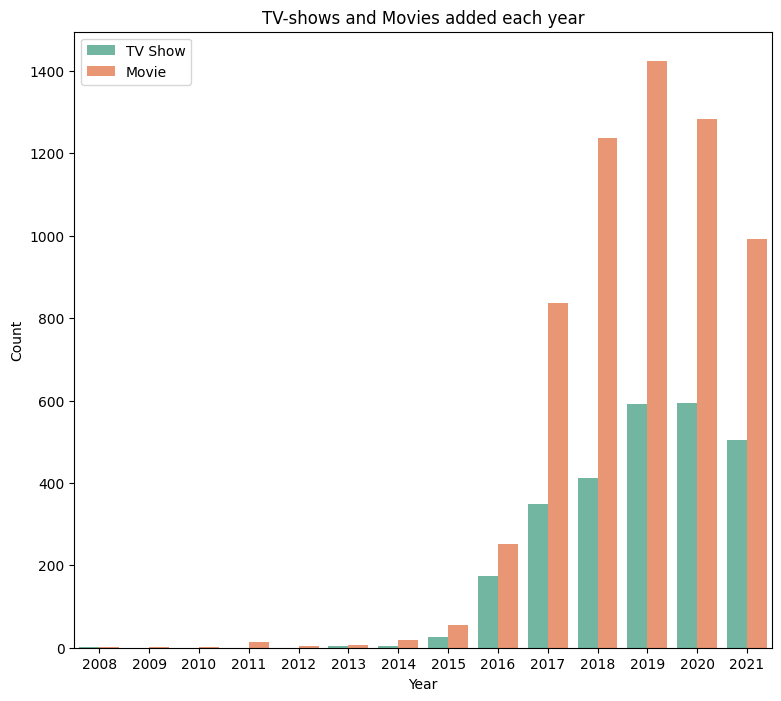

In [ ]:
plt.figure(figsize=(9,8))
sns.barplot(x='Year',y='Count',hue='Type',data=df_mov_tv,palette='Set2')
plt.title('TV-shows and Movies added each year')
plt.legend(loc='upper left')
plt.show()

13. What is the distribution of release years for movies and TV-shows?

In [ ]:
movies = df_netflix[df_netflix['type'] == 'Movie']
tv_shows = df_netflix[df_netflix['type'] == 'TV Show']

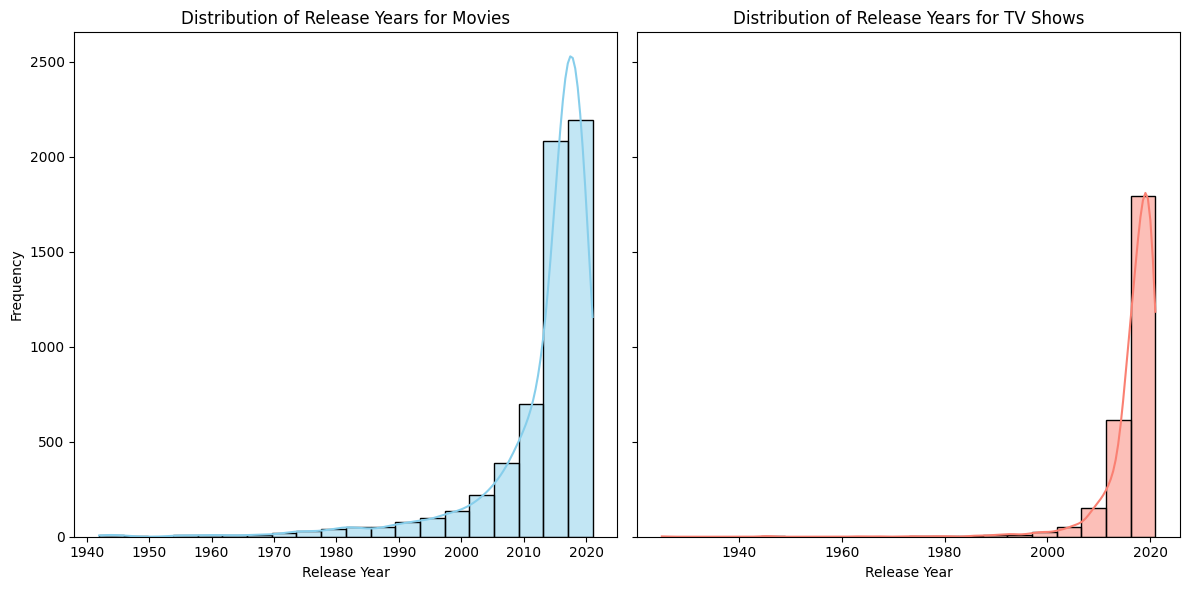

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6),sharey=True)

sns.histplot(data=movies, x='release_year', bins=20, kde=True, ax=ax1, color='skyblue')
ax1.set_title('Distribution of Release Years for Movies')
ax1.set_xlabel('Release Year')
ax1.set_ylabel('Frequency')

sns.histplot(data=tv_shows, x='release_year', bins=20, kde=True, ax=ax2, color='salmon')
ax2.set_title('Distribution of Release Years for TV Shows')
ax2.set_xlabel('Release Year')
ax2.set_ylabel('Frequency')

# Adjust layout
plt.tight_layout()

plt.show()

14. What are the top 5 most common words in the "description" column?

In [ ]:
# extracting the description column as list
df_descp = list(df_netflix['description'])
df_descp

['As her father nears the end of his life, filmmaker Kirsten Johnson stages his death in inventive and comical ways to help them both face the inevitable.',
 'After crossing paths at a party, a Cape Town teen sets out to prove whether a private-school swimming star is her sister who was abducted at birth.',
 'To protect his family from a powerful drug lord, skilled thief Mehdi and his expert team of robbers are pulled into a violent and deadly turf war.',
 'Feuds, flirtations and toilet talk go down among the incarcerated women at the Orleans Justice Center in New Orleans on this gritty reality series.',
 'In a city of coaching centers known to train India’s finest collegiate minds, an earnest but unexceptional student and his friends navigate campus life.',
 'The arrival of a charismatic young priest brings glorious miracles, ominous mysteries and renewed religious fervor to a dying town desperate to believe.',
 "Equestria's divided. But a bright-eyed hero believes Earth Ponies, Pegas

In [ ]:
# converting the list to str to split
cnm_lst = str(df_descp).split(' ')
cnm_lst

["['As",
 'her',
 'father',
 'nears',
 'the',
 'end',
 'of',
 'his',
 'life,',
 'filmmaker',
 'Kirsten',
 'Johnson',
 'stages',
 'his',
 'death',
 'in',
 'inventive',
 'and',
 'comical',
 'ways',
 'to',
 'help',
 'them',
 'both',
 'face',
 'the',
 "inevitable.',",
 "'After",
 'crossing',
 'paths',
 'at',
 'a',
 'party,',
 'a',
 'Cape',
 'Town',
 'teen',
 'sets',
 'out',
 'to',
 'prove',
 'whether',
 'a',
 'private-school',
 'swimming',
 'star',
 'is',
 'her',
 'sister',
 'who',
 'was',
 'abducted',
 'at',
 "birth.',",
 "'To",
 'protect',
 'his',
 'family',
 'from',
 'a',
 'powerful',
 'drug',
 'lord,',
 'skilled',
 'thief',
 'Mehdi',
 'and',
 'his',
 'expert',
 'team',
 'of',
 'robbers',
 'are',
 'pulled',
 'into',
 'a',
 'violent',
 'and',
 'deadly',
 'turf',
 "war.',",
 "'Feuds,",
 'flirtations',
 'and',
 'toilet',
 'talk',
 'go',
 'down',
 'among',
 'the',
 'incarcerated',
 'women',
 'at',
 'the',
 'Orleans',
 'Justice',
 'Center',
 'in',
 'New',
 'Orleans',
 'on',
 'this',
 'gritty

In [ ]:
# counting each word using counter function and stored as dictionary
all_words = [words for words in cnm_lst]

# Count word frequencies
word_counts = Counter(all_words)
word_counts

Counter({"['As": 1,
         'her': 2067,
         'father': 160,
         'nears': 3,
         'the': 7704,
         'end': 45,
         'of': 5260,
         'his': 3331,
         'life,': 67,
         'filmmaker': 45,
         'Kirsten': 1,
         'Johnson': 2,
         'stages': 13,
         'death': 119,
         'in': 3676,
         'inventive': 5,
         'and': 6294,
         'comical': 5,
         'ways': 34,
         'to': 6335,
         'help': 265,
         'them': 230,
         'both': 88,
         'face': 106,
         "inevitable.',": 1,
         "'After": 449,
         'crossing': 4,
         'paths': 48,
         'at': 683,
         'a': 10092,
         'party,': 17,
         'Cape': 4,
         'Town': 4,
         'teen': 195,
         'sets': 129,
         'out': 417,
         'prove': 56,
         'whether': 22,
         'private-school': 2,
         'swimming': 4,
         'star': 105,
         'is': 1102,
         'sister': 58,
         'who': 803,
         'was

In [ ]:
# sorting the dictionary in descending order on value
desc_word = sorted(word_counts.items(), key=lambda x:x[1],reverse=True)
desc_word

[('a', 10092),
 ('the', 7704),
 ('to', 6335),
 ('and', 6294),
 ('of', 5260),
 ('in', 3676),
 ('his', 3331),
 ('with', 2142),
 ('her', 2067),
 ('for', 1761),
 ('an', 1711),
 ('on', 1660),
 ('their', 1659),
 ('from', 1193),
 ('is', 1102),
 ('as', 1081),
 ("'A", 1067),
 ('by', 998),
 ('this', 970),
 ('he', 860),
 ('that', 818),
 ('who', 803),
 ('when', 766),
 ('into', 711),
 ('young', 686),
 ('at', 683),
 ('–', 605),
 ('up', 570),
 ('life', 569),
 ('but', 568),
 ("'When", 554),
 ('new', 540),
 ('they', 529),
 ("'In", 528),
 ('she', 463),
 ("'After", 449),
 ('family', 446),
 ('man', 441),
 ('after', 420),
 ('out', 417),
 ('woman', 415),
 ('"A', 403),
 ('must', 397),
 ('are', 382),
 ('friends', 359),
 ('two', 357),
 ('love', 356),
 ('about', 351),
 ('him', 345),
 ('find', 331),
 ('finds', 312),
 ('documentary', 309),
 ('where', 300),
 ('one', 299),
 ("'This", 293),
 ('world', 291),
 ('series', 284),
 ('—', 279),
 ('while', 276),
 ('be', 274),
 ('takes', 273),
 ('has', 271),
 ('help', 265),


In [ ]:
# unzipping the list of tuples into list of lists
unzip_wrd_lst = [list(i) for i in zip(*desc_word[:5])]
unzip_wrd_lst

[['a', 'the', 'to', 'and', 'of'], [10092, 7704, 6335, 6294, 5260]]

In [ ]:
# storingt the lists in different variable using indexing
word = unzip_wrd_lst[0]
num = unzip_wrd_lst[1]

print(word)
print(num)

['a', 'the', 'to', 'and', 'of']
[10092, 7704, 6335, 6294, 5260]


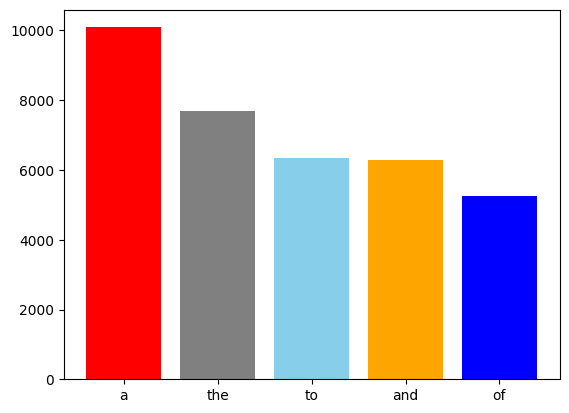

In [ ]:
plt.bar(word,num,color=['r','gray','skyblue','orange','blue'])
plt.show()

15. Is there any correlation between the release year and the rating of content?

In [ ]:
df_2 = df_netflix[['release_year','rating']]
df_2.corr()

<ipython-input-138-18e90130c870>:2: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  df_2.corr()


,release_year
release_year,1.0


There is no correlation between release year and rating because to correlate, columns should be numeric only.